In [2]:
import pandas as pd
df = pd.read_csv("../data/cleaned/final_dataset_clustered.csv")


In [14]:
df.head()

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,department_Surgery,"location_Houston, TX","location_Los Angeles, CA","location_New York, NY","location_Phoenix, AZ",readmitted_>30,readmitted_NO,diabetesMed_Yes,change_No,Cluster
0,15,1,1,7,3,59,0,18,0,0,...,0,0,0,1,0,1,0,1,0,2
1,25,1,1,7,2,11,5,13,2,0,...,0,0,0,1,0,0,1,1,1,3
2,35,1,1,7,2,44,1,16,0,0,...,0,0,0,0,0,0,1,1,0,2
3,45,1,1,7,1,51,0,8,0,0,...,0,0,0,0,0,0,1,1,0,2
4,55,2,1,2,3,31,6,16,0,0,...,0,1,0,0,0,1,0,1,1,3


In [15]:
df.shape

(98053, 57)

In [16]:
print(df.columns.tolist())

['age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'bed_occupancy', 'patient_satisfaction', 'length_of_stay', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'gender_Male', 'gender_Unknown/Invalid', 'department_Endocrinology', 'department_General Medicine', 'department_Neurology', 'department_Surgery', 'location_Houston, TX', 'location_Los Angeles, CA', 'location_New York, NY', 'location_Phoenix, AZ', 'readm

In [20]:
df['Cluster'].value_counts()


Cluster
3    43648
2    33155
1    19266
0     1984
Name: count, dtype: int64

In [22]:
cluster_size = df['Cluster'].value_counts(normalize=True)*100
print(cluster_size)

Cluster
3    44.514701
2    33.813346
1    19.648557
0     2.023396
Name: proportion, dtype: float64


In [12]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

               age  admission_type_id  discharge_disposition_id  \
Cluster                                                           
0        59.228831           2.318548                  3.351310   
1        68.459981           2.042354                  5.494602   
2        64.915850           2.015262                  3.126708   
3        66.630315           2.013219                  3.479083   

         admission_source_id  time_in_hospital  num_lab_procedures  \
Cluster                                                              
0                   6.150202          4.104839           42.875000   
1                   5.565660          9.002491           55.821084   
2                   5.855648          3.379309           40.551832   
3                   5.792889          3.206584           39.538788   

         num_procedures  num_medications  number_outpatient  number_emergency  \
Cluster                                                                         
0             

In [5]:
df.groupby('Cluster')['age'].mean()

Cluster
0    59.228831
1    68.459981
2    64.915850
3    66.630315
Name: age, dtype: float64

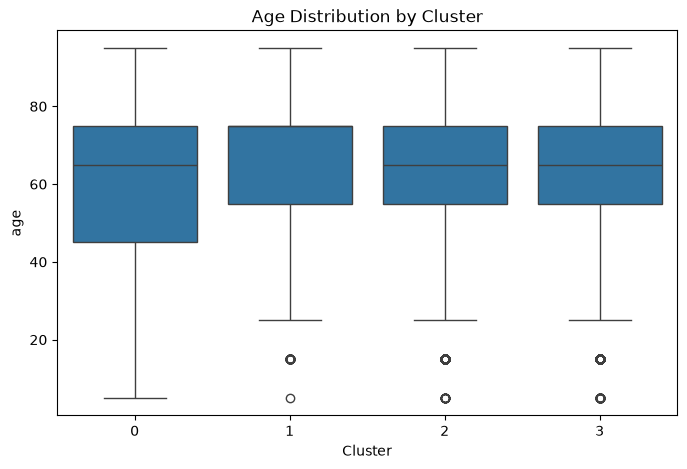

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Cluster',
    y='age',
    data=df
)
plt.title('Age Distribution by Cluster')
plt.show()


In [8]:
utilization_features = [
    'time_in_hospital',
    'num_medications',
    'number_inpatient',
    'number_outpatient'
]

df.groupby('Cluster')[utilization_features].mean()


,time_in_hospital,num_medications,number_inpatient,number_outpatient
Cluster,,,,
0,4.104839,14.182460,0.621472,0.332661
1,9.002491,24.653639,0.847815,0.380774
2,3.379309,15.664183,0.634414,0.418549
3,3.206584,12.786817,0.568777,0.344391


In [17]:
pd.crosstab(
    df['Cluster'],
    df['readmitted_NO'],
    normalize='index'
)*100

readmitted_NO,0,1
Cluster,,
0,42.338710,57.661290
1,51.079622,48.920378
2,48.544714,51.455286
3,43.390304,56.609696


In [16]:
pd.crosstab(
    df['Cluster'],
    df['readmitted_>30'],
    normalize='index'
)*100


readmitted_>30,0,1
Cluster,,
0,68.094758,31.905242
1,62.747846,37.252154
2,62.756749,37.243251
3,66.800312,33.199688


In [15]:
pd.crosstab(df['Cluster'],df['gender_Male'])

gender_Male,0,1
Cluster,,
0,1068,916
1,10623,8643
2,17443,15712
3,23700,19948


In [18]:
pd.crosstab(df['Cluster'],df['gender_Unknown/Invalid'])

gender_Unknown/Invalid,0,1
Cluster,,
0,1984,0
1,19266,0
2,33154,1
3,43648,0


In [3]:
pd.crosstab(df['Cluster'],df['race_Asian'])

race_Asian,0,1
Cluster,,
0,1984,0
1,19169,97
2,32952,203
3,43323,325


In [4]:
pd.crosstab(df['Cluster'],df['race_Caucasian'])

race_Caucasian,0,1
Cluster,,
0,1984,0
1,4205,15061
2,7320,25835
3,9465,34183


In [5]:
pd.crosstab(df['Cluster'],df['race_Hispanic'])

race_Hispanic,0,1
Cluster,,
0,0,1984
1,19266,0
2,33155,0
3,43648,0


In [6]:
pd.crosstab(df['Cluster'],df['race_Other'])

race_Other,0,1
Cluster,,
0,1984,0
1,18973,293
2,32553,602
3,43059,589


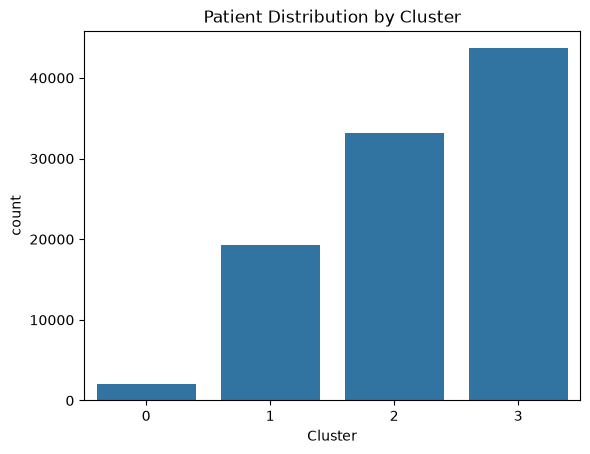

In [10]:

import seaborn as sns
sns.countplot(
    x='Cluster',
    data=df
)
plt.title('Patient Distribution by Cluster')
plt.show()


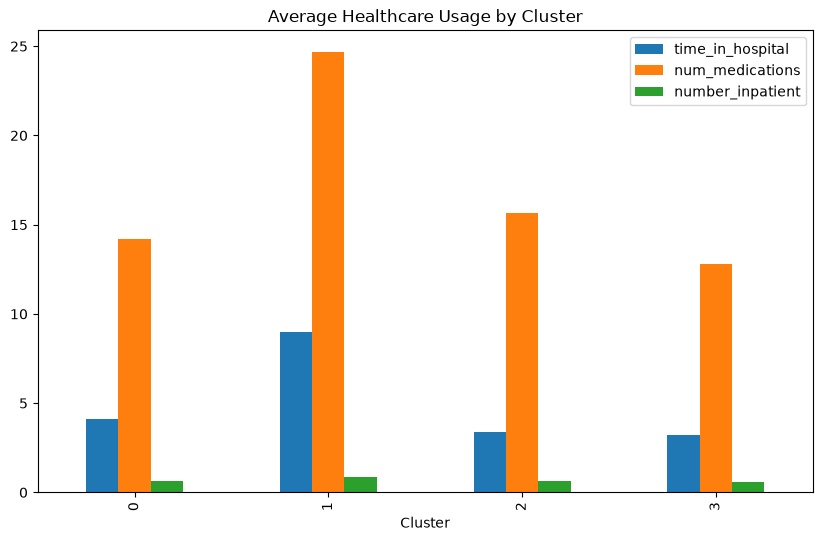

In [13]:
cluster_summary[
[
    'time_in_hospital',
    'num_medications',
    'number_inpatient'
]
].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Average Healthcare Usage by Cluster')
plt.show()
